In [1]:
import os
import math
import graphufs
import xrft

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import typing as t
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import colormaps as cm
import matplotlib.cm as mcm

from matplotlib.lines import Line2D
from weatherbench2 import schema

#from weatherbench2.derived_variables import ZonalEnergySpectrum

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
class DerivedVariable:
  """Derived variable base class."""

  @property
  def base_variables(self) -> list[str]:
    """Return a list of base variables."""
    return []

  @property
  def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
    """Return core dimensions needed for computing this variable.

    Returns a tuple, where the first element is a tuple of all core dimensions
    for input (base) variables, and the second element is a tuple of all core
    dimensions on the output. For more details on the concept of "core
    dimensions", see xarray.apply_ufunc.
    """
    raise NotImplementedError

  @property
  def all_input_core_dims(self) -> set[str]:
    """The set of all input core dimensions."""
    return set().union(*self.core_dims[0])

  def compute(self, dataset: xr.Dataset) -> xr.DataArray:
    """Compute derived variable, returning it in a new DataArray."""
    raise NotImplementedError

In [4]:
class ZonalEnergySpectrum_local(DerivedVariable):
  """Energy spectrum along the zonal direction.

  Given dataset with longitude dimension, this class computes spectral energy as
  a function of wavenumber (as a dim). wavelength and frequency are also present
  as coords with units "1 / m" and "m" respectively. Only non-negative
  frequencies are included.

  Let f[l], l = 0,..., L - 1, be dataset values along a zonal circle of constant
  latitude, with circumference C (m).  The DFT is
    F[k] = (1 / L) Σₗ f[l] exp(-i2πkl/L)
  The energy spectrum is then set to
    S[0] = C |F[0]|²,
    S[k] = 2 C |F[k]|², k > 0, to account for positive and negative frequencies.

  With C₀ the equatorial circumference, the ith zonal circle has circumference
    C(i) = C₀ Cos(π latitude[i] / 180).
  Since data points occur at longitudes longitude[l], l = 0, ..., L - 1, the DFT
  will measure spectra at zonal sampling frequencies
    f(k, i) = longitude[k] / (C(i) 360), k = 0, ..., L // 2,
  and corresponding wavelengths
    λ(k, i) = 1 / f(k, i).

  This choice of normalization ensures Parseval's relation for energy holds:
  Supposing f[l] are sampled values of f(ℓ), where 0 < ℓ < C (meters) is a
  coordinate on the circle. Then (C / L) is the spacing of longitudinal samples,
  whence
    ∫|f(ℓ)|² dℓ ≈ (C / L) Σₗ |f[l]|² = Σₖ S[k].

  If f has units β, then S has units of m β². For example, if f is
  `u_component_of_wind`, with units (m / s), then S has units (m³ / s²). In
  air with mass density ρ (kg / m³), this gives energy density at wavenumber k
    ρ S[k] ~ (kg / m³) (m³ / s²) = kg / s²,
  which is energy density (per unit area).
  """

  variable_name: str

  @property
  def base_variables(self) -> list[str]:
    return [self.variable_name]

  @property
  def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
    return (['longitude'],), ['zonal_wavenumber']

  def _circumference(self, dataset: xr.Dataset) -> xr.DataArray:
    """Earth's circumference as a function of latitude."""
    circum_at_equator = 2 * np.pi * schema.EARTH_RADIUS_M
    return np.cos(dataset.latitude * np.pi / 180) * circum_at_equator

  def lon_spacing_m(self, dataset: xr.Dataset) -> xr.DataArray:
    """Spacing (meters) between longitudinal values in `dataset`."""
    diffs = dataset.longitude.diff('longitude')
    if np.max(np.abs(diffs - diffs[0])) > 1e-3:
      raise ValueError(
          f'Expected uniform longitude spacing. {dataset.longitude.values=}'
      )
    return self._circumference(dataset) * diffs[0].data / 360

  def compute(self, dataset: xr.Dataset) -> xr.DataArray:
    """Computes zonal power at wavenumber and frequency."""
    spacing = self.lon_spacing_m(dataset)

    def simple_power(f_x):
      f_k = np.fft.rfft(f_x, axis=-1, norm='forward')
      # freq > 0 should be counted twice in power since it accounts for both
      # positive and negative complex values.
      one_and_many_twos = np.concatenate(([1], [2] * (f_k.shape[-1] - 1)))
      return np.real(f_k * np.conj(f_k)) * one_and_many_twos

    spectrum = xr.apply_ufunc(
        simple_power,
        dataset,
        input_core_dims=[['longitude']],
        output_core_dims=[['longitude']],
        exclude_dims={'longitude'},
    ).rename_dims({'longitude': 'zonal_wavenumber'})#[self.variable_name]
    spectrum = spectrum.assign_coords(
        zonal_wavenumber=('zonal_wavenumber', spectrum.zonal_wavenumber.data)
    )
    base_frequency = xr.DataArray(
        np.fft.rfftfreq(len(dataset.longitude)),
        dims='zonal_wavenumber',
        coords={'zonal_wavenumber': spectrum.zonal_wavenumber},
    )
    spectrum = spectrum.assign_coords(frequency=base_frequency / spacing)
    spectrum['frequency'] = spectrum.frequency.assign_attrs(units='1 / m')

    spectrum = spectrum.assign_coords(wavelength=1 / spectrum.frequency)
    spectrum['wavelength'] = spectrum.wavelength.assign_attrs(units='m')

    # This last step ensures the sum of spectral components is equal to the
    # (discrete) integral of data around a line of latitude.
    return spectrum * self._circumference(spectrum)

In [5]:
class Vorticity(DerivedVariable):
    """Compute relative vorticity from velocity fields."""

    R = 6.371e6  # Earth's radius [m]

    @property
    def base_variables(self) -> list[str]:
        return ["uo", "vo"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"], ["time", "lat", "lon"]],   # uo, vo
            ["time", "lat", "lon"],                             # vorticity
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        u = dataset["uo"]
        v = dataset["vo"]
        lat = u["lat"]
        lon = u["lon"]

        # Convert degrees to radians
        lat_rad = np.deg2rad(lat)
        lon_rad = np.deg2rad(lon)

        # Grid spacing
        dlat = xr.DataArray(np.gradient(lat_rad.values), coords={"lat": lat}, dims=["lat"])
        dlon = xr.DataArray(np.gradient(lon_rad.values), coords={"lon": lon}, dims=["lon"])

        # dx depends on both lat and lon — lat_rad must broadcast with dlon
        dx = self.R * np.cos(lat_rad) * dlon  # (lat, lon) via xarray broadcasting
        dy = self.R * dlat                     # (lat,)

        # Compute gradients
        dv_dx = v.differentiate("lon") / dx
        du_dy = u.differentiate("lat") / dy

        # Vorticity
        vort = dv_dx - du_dy
        vort.name = "vorticity"
        
        return vort

In [6]:
class GeostrophicVelocity(DerivedVariable):
    """Compute geostrophic velocity from SSH."""

    g = 9.81        # gravitational acceleration [m/s^2]
    R = 6.371e6     # Earth radius [m]
    omega = 7.2921e-5  # rad/s

    @property
    def base_variables(self) -> list[str]:
        return ["ssh"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"]],             # SSH input
            ["time", "lat", "lon"],               # Output: ug, 
            ["time", "lat", "lon"],               # Output: vg,
            ["time", "lat", "lon"]                # Output: speed
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        ssh = dataset["ssh"]
        lat = ssh["lat"]
        lon = ssh["lon"]

        lat2d, lon2d = np.meshgrid(lat, lon, indexing="ij")
        da_lat2d = xr.DataArray(lat2d, dims=("lat", "lon"),
                                coords = {"lat":lat.values, "lon":lon.values})

        f = 2 * self.omega * np.sin((np.pi/180) * da_lat2d)
        f = f.where(np.abs(f)>1e-5, np.nan)

        # u geostrophic: (-g/fR)*deta/dy
        ugeo = (-self.g/f) * ssh.differentiate("lat") / (np.pi/180)/self.R
        ugeo.name = "geostrophic_velocity-U"
        
        # v geostrophic: (g/fRcos\theta)*dh/dx
        vgeo = (self.g/f) * ssh.differentiate("lon") / (np.pi/180)/(self.R * np.cos((np.pi/180) * da_lat2d)) 
        vgeo.name = "geostrophic_velocity-V"
        
        # geostrophic current speed 
        speedgeo = np.sqrt(ugeo**2 + vgeo**2)
        speedgeo.name = "geostrophic_current_speed"

        return geo_vel

In [7]:
class KineticEnergy(DerivedVariable):
    """Compute kinetic energy from velocity fields."""

    @property
    def base_variables(self) -> list[str]:
        return ["uo", "vo"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"], ["time", "lat", "lon"]],  # uo, vo
            ["time", "lat", "lon"],                            # KE
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        u = dataset["uo"]
        v = dataset["vo"]

        ke = 0.5 * (u**2 + v**2)
        ke.name = "kinetic_energy"
        
        return ke

In [8]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates,
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

# Meta, Config, and Data

In [9]:
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
FIG_DIR = os.path.join(os.getcwd(), "figures")
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
TRUTHS = ["REPLAY"]
MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]
VAR_LIST = ["SSH", "temp", "so", "uo", "vo"]

In [10]:
duration = "240h"
model_inferences = {}
reference_truths = {}
        
for model_config in MODELS_CONFIG:

    model_name = model_config["name"]
    print(f"Processing Model: {model_name}")

    # get the model inference data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
    model_inferences[model_config["name"]] = model_pred

    # loop over the reference truths. Note that I'm not including the code block for the persistence 
    # and climatology reference. If you need to support these, use this code block in figure3.ipynb 
    for truth in TRUTHS:
        
        infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
        fname = f"{location}/{truth.lower()}.{model_config['duration']}.zarr"
        ref_truth = xr.open_zarr(fname)
        reference_truths[truth] = ref_truth.sel(time=slice(EVALUATION_DATES[0], EVALUATION_DATES[1]))
        
        if truth.lower() == "Replay".lower(): 
            mask_2d = xr.where(reference_truths[truth]["SSH"].isel(time=0, lead_time=0)==0, 0, 1) # approximately correct
            mask_3d = xr.where(reference_truths[truth]["so"].isel(time=0, lead_time=0)==0, 0, 1)

            # impute the land regions as nans in model and reference truth 
            for var in reference_truths[truth].data_vars:
                if var.lower() == "ssh":
                    reference_truths[truth]["SSH"] = reference_truths[truth]["SSH"].where(mask_2d, other=0)
                    model_inferences[model_name]["SSH"] = model_inferences[model_name]["SSH"].where(mask_2d, other=0)
                else:
                    reference_truths[truth][var] = reference_truths[truth][var].where(mask_3d, other=0)
                    model_inferences[model_name][var] = model_inferences[model_name][var].where(mask_3d, other=0)

Processing Model: Emulator-24h-MSE
Processing Model: Emulator-24h-Maha


# Zonal Spectra

In [ ]:
# Initialize
spectra_model = {}
spectra_truth = {}

zspec = ZonalEnergySpectrum_local()
for model in model_inferences.keys():
    spectra_model[model] = zspec.compute(dataset = model_inferences[model].rename({"lat":"latitude","lon":"longitude"}).isel(time=0).load())
for truth in reference_truths.keys():
    spectra_truth[truth] = zspec.compute(dataset = reference_truths[truth].rename({"lat":"latitude","lon":"longitude"}).isel(time=0).load())

In [12]:
model_inferences["Emulator-24h-Maha"]

<xarray.Dataset> Size: 100GB
Dimensions:    (time: 292, lead_time: 40, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 320B 1 days 2 days ... 40 days
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 2kB 2022-01-01 ... 2022-12-30T18:00:00
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (time, lead_time, lat, lon) float32 3GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    so         (time, lead_time, z_l, lat, lon) float32 24GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    temp       (time, lead_time, z_l, lat, lon) float32 24GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    uo         (time, lead_time, z_l, lat, lon) float32 24GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    vo         (time, lead_time, z_l, lat, lon) float32 24GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>

## Plot latitude-mean zonal spectra

In [11]:
def plot_spectra_2d(
    spectra_inference: dict,
    spectra_truth: dict = None,
    lead_time: list = ["24h"],
    fields: tuple = ("SSH",),
    labels: tuple = None,
    suptitle: str = None,
    zoom: bool = False,
    save: bool = False,
    save_path: str = None,
):
    """
    Plot zonal spectra for multiple lead times and fields.

    Parameters:
    - spectra_inference: xarray.Dataset containing spectra from model
    - spectra_truth: xarray.Dataset containing spectra from truth
    - lead_time: list of strings (e.g. ["24h", "48h"])
    - fields: tuple of variable names
    - labels: tuple of display names for variables
    - zoom: whether to zoom into log scale region
    - save: whether to save figure
    - save_path: filename to save (required if save=True)
    """

    # Convert string lead times to np.timedelta64[h]
    lead_times_td = [np.timedelta64(int(t[:-1]), "h") for t in lead_time]

    
    nrows = len(fields)
    ncols = len(lead_times_td)
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.5 * ncols, 4.5 * nrows), 
                            sharey="row", squeeze=False)
    
    for j, lt_td in enumerate(lead_times_td):
        for i, field in enumerate(fields):
            ax = axs[i, j]

            for model in spectra_inference.keys():
                da_inf = spectra_inference[model][field].sel(lead_time=lt_td).mean("latitude")

                # mean over all ICs
                if "time" in da_inf.dims:
                    da_inf = da_inf.mean("time")

                # plot
                da_inf.plot(ax=ax, x="zonal_wavenumber", label=f"{model}", linewidth=2)
                    
            if spectra_truth is not None:
                for truth in spectra_truth.keys():
                    da_truth = spectra_truth[truth][field].sel(lead_time=lt_td,).mean("latitude")

                    if "time" in da_truth.dims:
                        da_truth = da_truth.mean("time")
                    
                    da_truth.plot(ax=ax, x="zonal_wavenumber", label=f"{truth}", linewidth=2)

            # Axis config
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlabel("Zonal Wavenumber")
            if j == 0:
                ax.set_ylabel("Spectral Power")
            else:
                ax.set_ylabel("")

            if zoom:
                ax.set_xlim(10, None)
                ax.set_ylim(None, 1e6)

            # Title
            label = labels[i] if labels else field.replace("_", "")
            ax.set_title(f"{label} | Lead Time: {lead_time[j]}")

            # Aesthetics
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.grid(True, linestyle=":", linewidth=0.5)

    # Legend outside plot
    handles, plot_labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, plot_labels, loc="upper right", bbox_to_anchor=(1.1, 0.7), fancybox=True, shadow=True)
    fig.suptitle(suptitle if suptitle is not None else f"Zonal spectra for {fields}")
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])

    if save and save_path:
        fig.savefig(save_path, dpi=300)

    return fig, axs

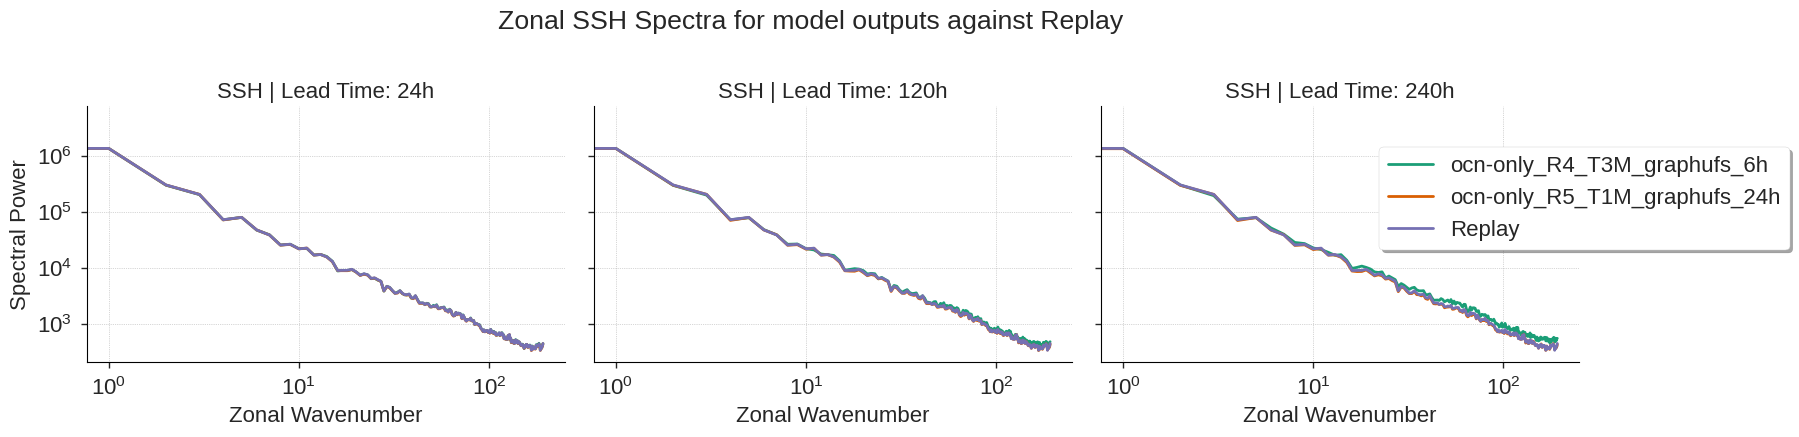

In [12]:
fields = ["SSH"]
fig, axs = plot_spectra_2d(spectra_model, 
                           spectra_truth, 
                           lead_time = ["24h", "120h", "240h"],
                           fields = fields,
                           labels = (["SSH"]),
                           suptitle="Zonal SSH Spectra for model outputs against Replay",
                           save = True,
                           save_path="./figures/compare_zonal_ssh_spectra_6h_vs_24h_against_replay.png"
                          )
plt.show()

In [19]:
def plot_spectra_grid_3d(
    spectra_inference: dict,
    spectra_truth: dict,
    variable: str = "temp",
    levels: list = [0, 50, 100],
    lead_times: list = ["24h", "48h"],
    zoom: bool = False,
    save: bool = False,
    save_path: str = None,
    suptitle: str = None,
):
    """
    Plot zonal spectra for a 3D variable with 'z_l' (depth) as rows and 'lead_time' as columns.

    Parameters:
    - spectra_inference: xarray.Dataset with spectra
    - spectra_truth: xarray.Dataset for ground truth
    - variable: 3D variable name (e.g., "temp")
    - levels: list of z_l (depth levels) to plot
    - lead_times: list of str lead times, e.g. ["24h", "48h"]
    - zoom: whether to zoom into log scale region
    - save: whether to save the figure
    - save_path: path to save the figure
    - title_prefix: string to prepend to each subplot title
    """
    # Convert lead times to timedelta64
    lead_times_td = [np.timedelta64(int(t[:-1]), "h") for t in lead_times]

    nrows = len(levels)
    ncols = len(lead_times_td)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5 * ncols, 3.5 * nrows), sharey="row",
                            sharex="all", squeeze=False)

    for i, z_val in enumerate(levels):
        for j, lt_td in enumerate(lead_times_td):
            ax = axs[i, j]

            for model in spectra_inference.keys():
                da_inf = spectra_inference[model][variable].sel(lead_time=lt_td).sel(z_l=z_val, method="nearest").mean("latitude")
                
                if "time" in da_inf.dims:
                    da_inf = da_inf.mean("time")

                # Plotting
                da_inf.plot(ax=ax, x="zonal_wavenumber", label=f"{model}", linewidth=2)

            if spectra_truth is not None:
                for truth in spectra_truth.keys():
                    da_truth = spectra_truth[truth][variable].sel(lead_time=lt_td).sel(z_l=z_val, method="nearest").mean("latitude")

                    if "time" in da_truth.dims:
                        da_truth = da_truth.mean("time")
                        
                    da_truth.plot(ax=ax, x="zonal_wavenumber", label=f"{truth}", linewidth=2)
            
            # Axes formatting
            ax.set_xscale("log")
            ax.set_yscale("log")
            if i == len(levels)-1:
                ax.set_xlabel("Zonal Wavenumber")
            else:
                ax.set_xlabel("")
            if j == 0:
                ax.set_ylabel(f"z_l = {da_truth.z_l.values:.2f}m")
            else:
                ax.set_ylabel("")

            if zoom:
                ax.set_xlim(10, None)
                ax.set_ylim(None, 1e6)
            if i == 0:
                title = f"Lead Time: {lead_times[j]}"
                ax.set_title(title,)
            else:
                ax.set_title("") # otherwise it puts those ugly xarray titles

            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.grid(True, linestyle=":", linewidth=0.5)

    # Legend and layout
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.2, 0.75), fancybox=True, shadow=True)
    fig.suptitle(suptitle if suptitle is not None else f"Zonal spectra for {fields}")
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])

    if save and save_path:
        fig.savefig(save_path, dpi=300)

    return fig, axs

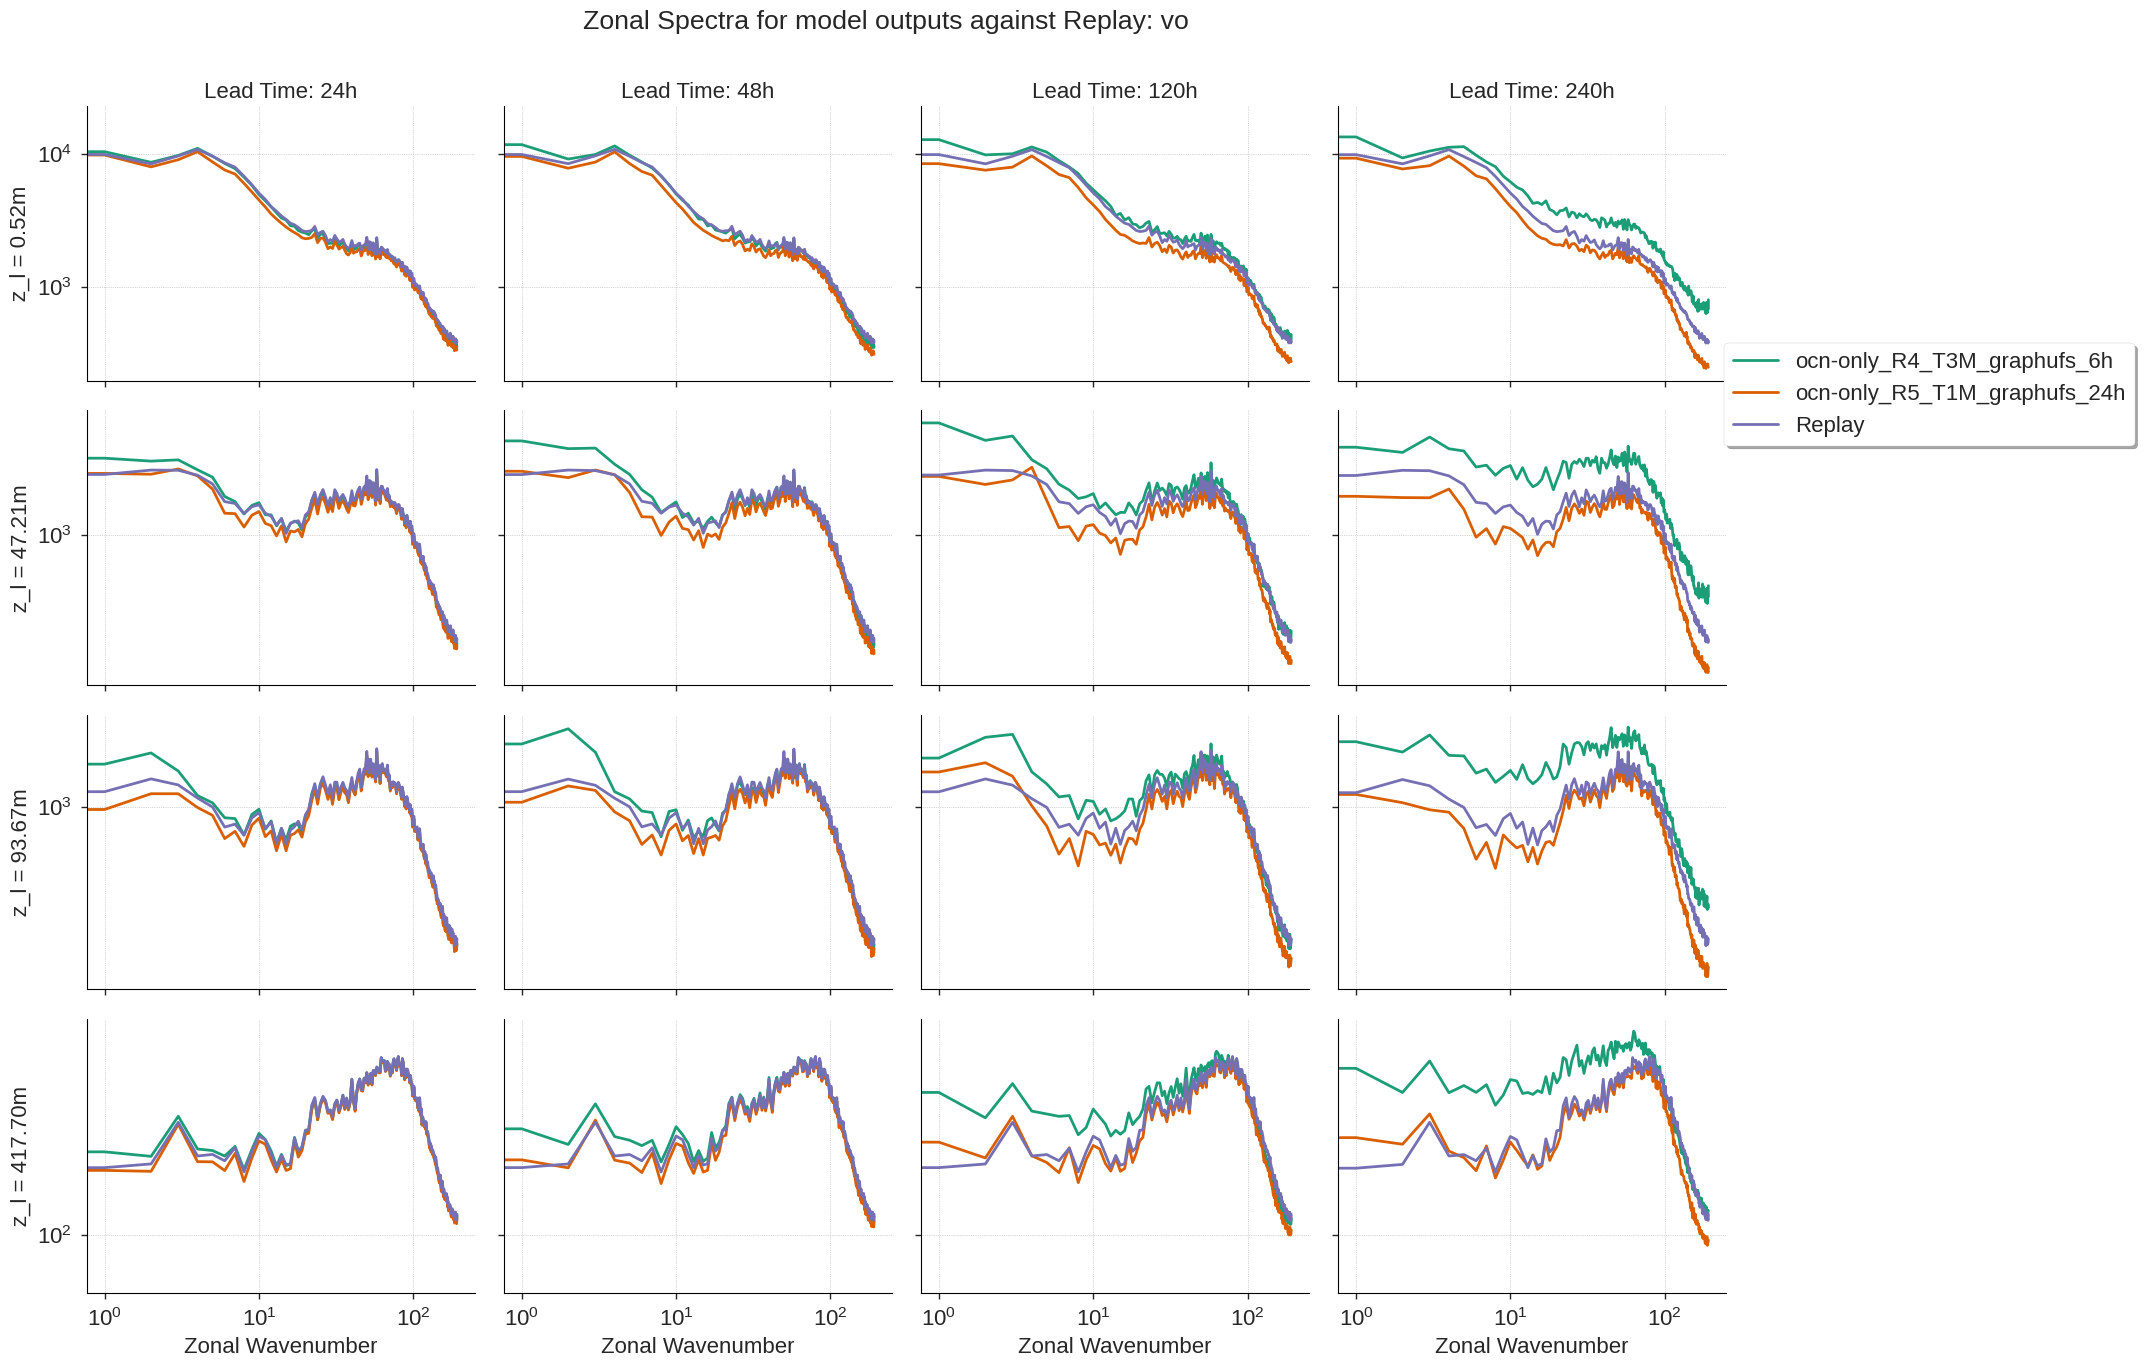

In [17]:
variable = "vo"

fig, axs = plot_spectra_grid_3d(
    spectra_inference=spectra_model,
    spectra_truth=spectra_truth,
    variable=variable,
    levels=[0, 50, 100, 400],
    lead_times=["24h", "48h", "120h", "240h"],
    suptitle=f"Zonal Spectra for model outputs against Replay: {variable}",
    save = True,
    save_path=f"./figures/compare_zonal_{variable}_spectra_6h_vs_24h_against_replay.png"
)

## Plot zonal spectra as a function of the latitude

In [30]:
def plot_zonal_spectra_map(spectra: xr.DataArray, 
                          title: str = "", 
                          cmap: str = "jet", 
                          log_scale: bool = True, 
                          vmin: float = None, 
                          vmax: float = None,
                          figsize=(8, 5),
                          save_path: str = None):
    """
    Plot 2D zonal spectra with latitude vs zonal wavenumber.

    Parameters:
    - spectra: xarray.DataArray with dims ("latitude", "zonal_wavenumber")
    - title: title of the plot
    - cmap: colormap for the heatmap
    - log_scale: use log10 for color normalization
    - vmin, vmax: value bounds for color scale
    - figsize: figure size
    - save_path: path to save the figure
    """

    if not {"latitude", "zonal_wavenumber"}.issubset(set(spectra.dims)):
        raise ValueError("Expected 'latitude' and 'zonal_wavenumber' in dimensions")

    data = spectra.values
    lats = spectra["latitude"].values
    wavenumbers = spectra["zonal_wavenumber"].values

    # Color scale
    if log_scale:
        data = np.log10(data)
        label = "log10(Spectral Power)"
    else:
        label = "Spectral Power"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.contourf(wavenumbers, lats, data, cmap=cmap, vmin=vmin, vmax=vmax)

    # Axis settings
    ax.set_xlabel("Zonal Wavenumber", fontsize=12, fontweight="bold")
    ax.set_ylabel("Latitude", fontsize=12, fontweight="bold")
    ax.set_title(title or "2D Zonal Spectra", fontsize=14, fontweight="bold")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)

    # Log scale for x-axis
    #ax.set_xscale("log")

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        
    plt.show()

/tmp/ipykernel_2079982/4127439859.py:31: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(data)


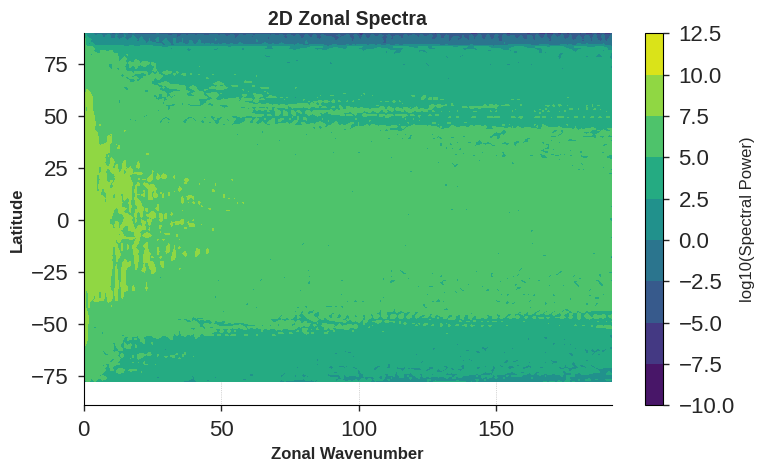

In [62]:
spectra = spectra_model["ocn-only_R5_T1M_graphufs_24h"]["temp"].isel(time=0, lead_time=-1, z_l=0)
plot_zonal_spectra_map(spectra, cmap="viridis") 
plt.show()

# Kinetic Energy Spectra

In [13]:
# Initialize
ke_model = {}
ke_truth = {}

ke = KineticEnergy()
for model in model_inferences.keys():
    ke_model[model] = ke.compute(dataset = model_inferences[model].load())
for truth in reference_truths.keys():
    ke_truth[truth] = ke.compute(dataset = reference_truths[truth].load())


KeyboardInterrupt



In [17]:
# Now compute the spectra
spectra_ke_model = {}
spectra_ke_truth = {}

zspec = ZonalEnergySpectrum_local()
for model in ke_model.keys():
    spectra_ke_model[model] = zspec.compute(dataset = ke_model[model].rename({"lat":"latitude","lon":"longitude"}).to_dataset(name="ke").load())
for truth in ke_truth.keys():
    spectra_ke_truth[truth] = zspec.compute(dataset = ke_truth[truth].rename({"lat":"latitude","lon":"longitude"}).to_dataset(name="ke").load())

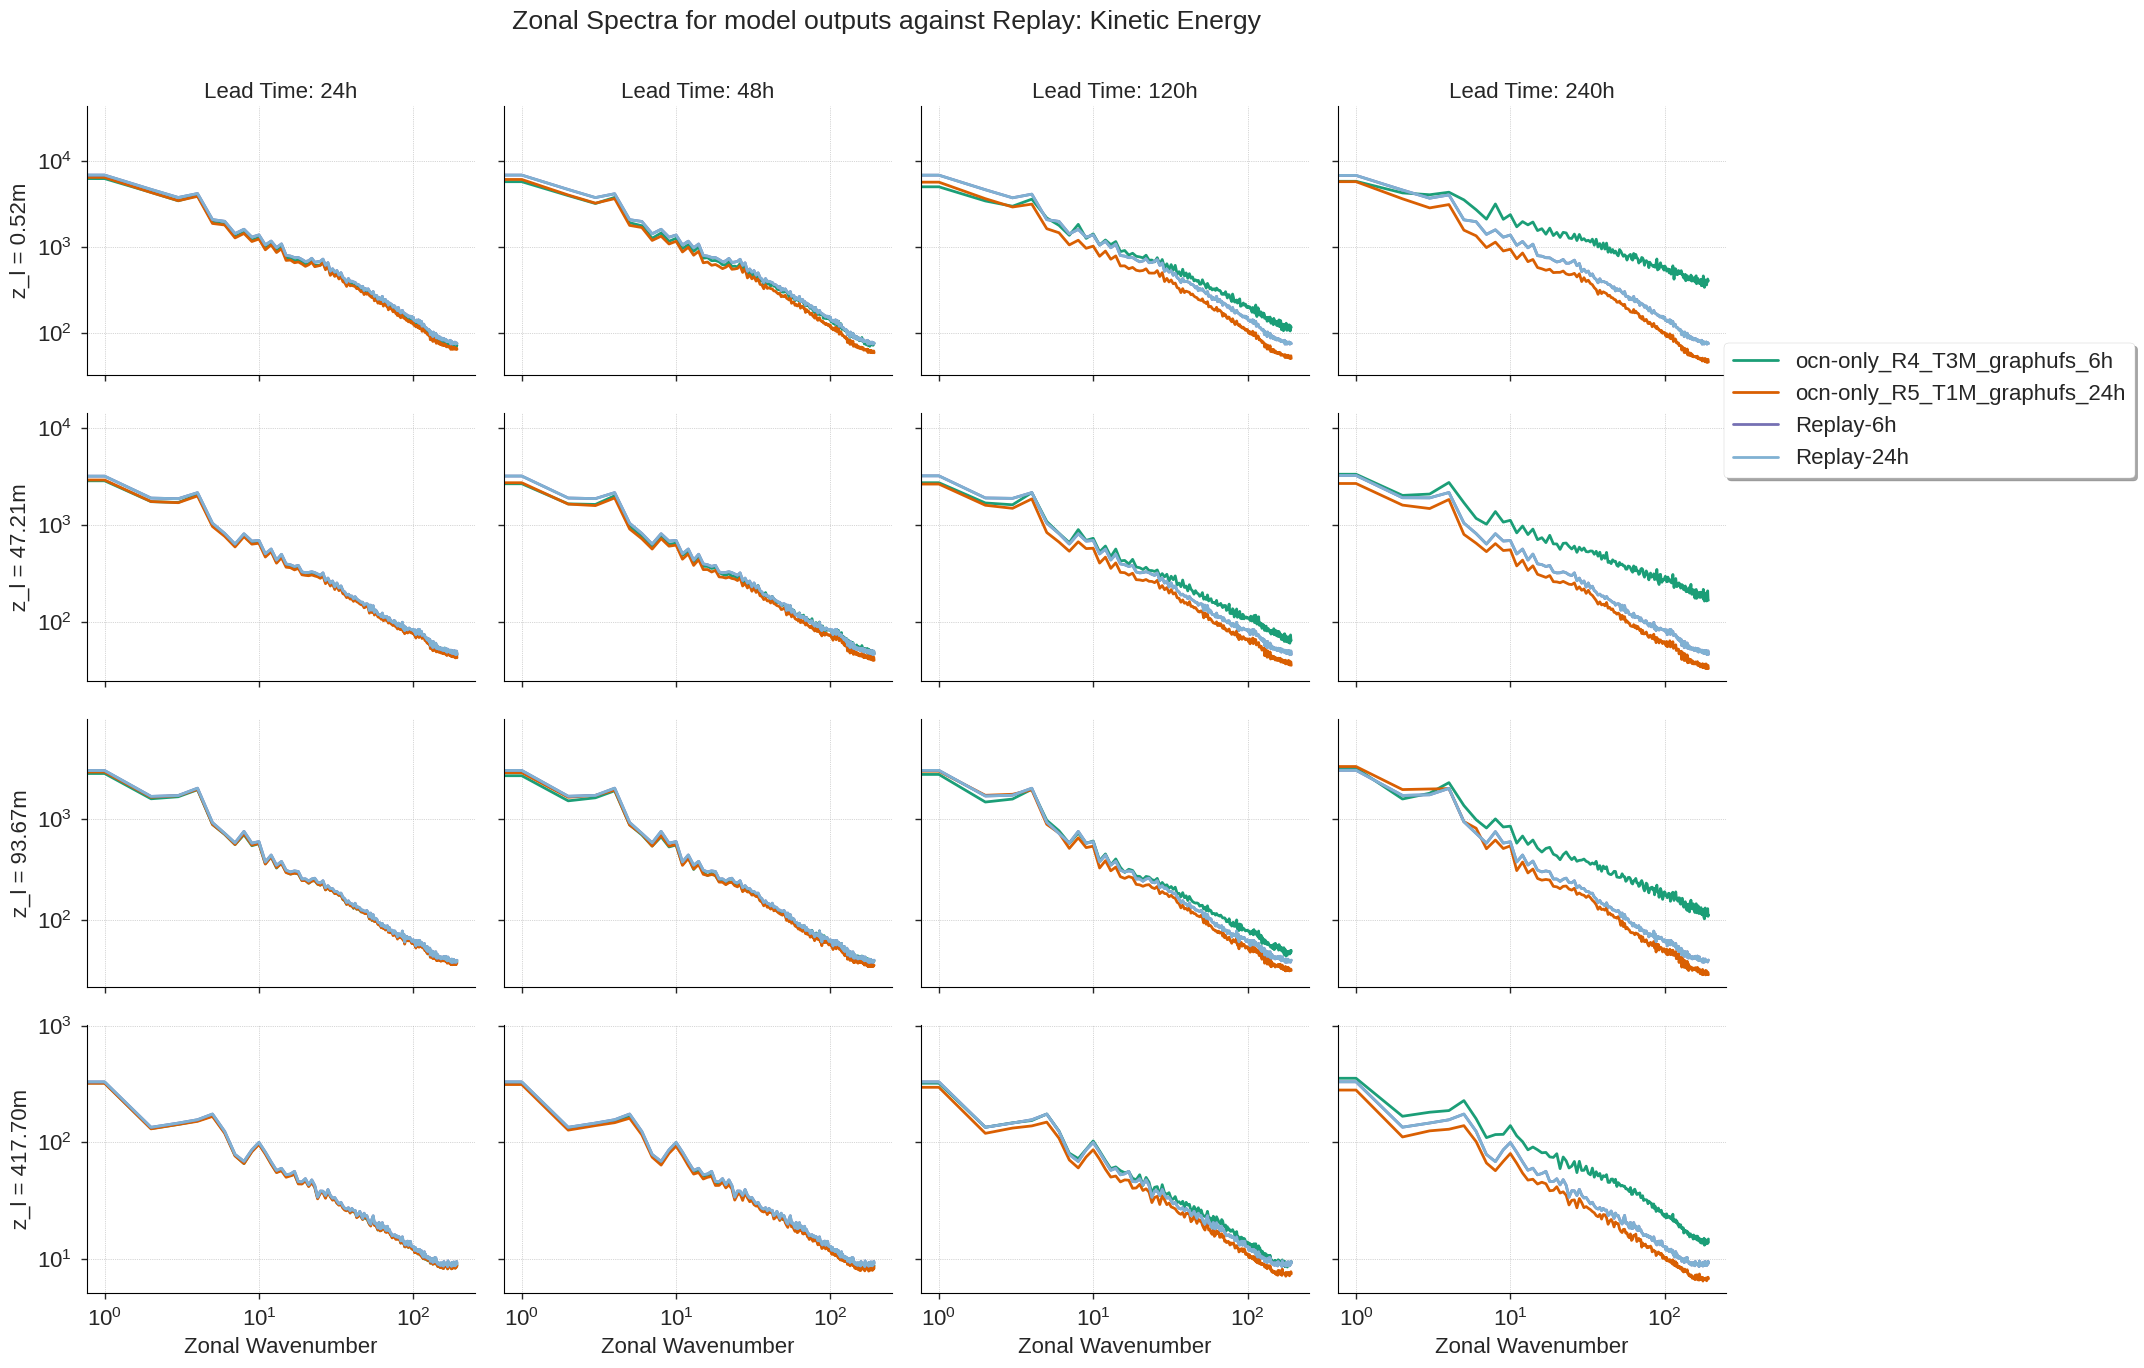

In [20]:
variable = "ke"

fig, axs = plot_spectra_grid_3d(
    spectra_inference=spectra_ke_model,
    spectra_truth=spectra_ke_truth,
    variable=variable,
    levels=[0, 50, 100, 400],
    lead_times=["24h", "48h", "120h", "240h"],
    suptitle=f"Zonal Spectra for model outputs against Replay: Kinetic Energy",
    save = False,
    save_path=f"./figures/compare_zonal_TKE_spectra_6h_vs_24h_against_replay.png"
)

/tmp/ipykernel_203337/4127439859.py:31: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(data)


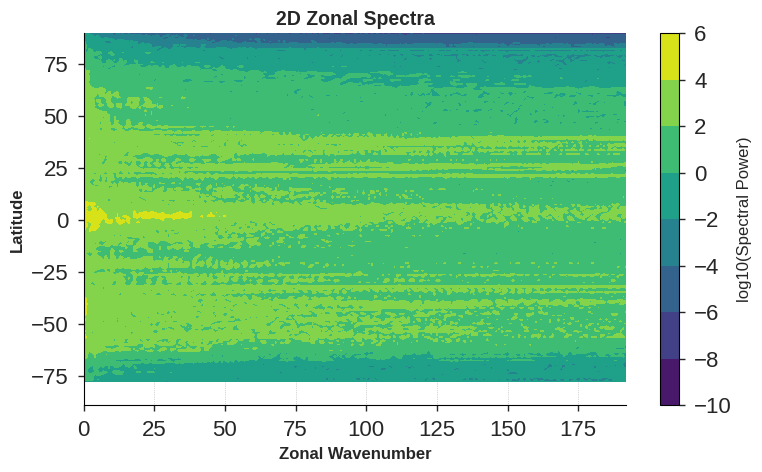

In [31]:
spectra = spectra_ke_model["ocn-only_R5_T1M_graphufs_24h"]["ke"].isel(time=0, lead_time=-1, z_l=0)
plot_zonal_spectra_map(spectra, cmap="viridis") 
plt.show()

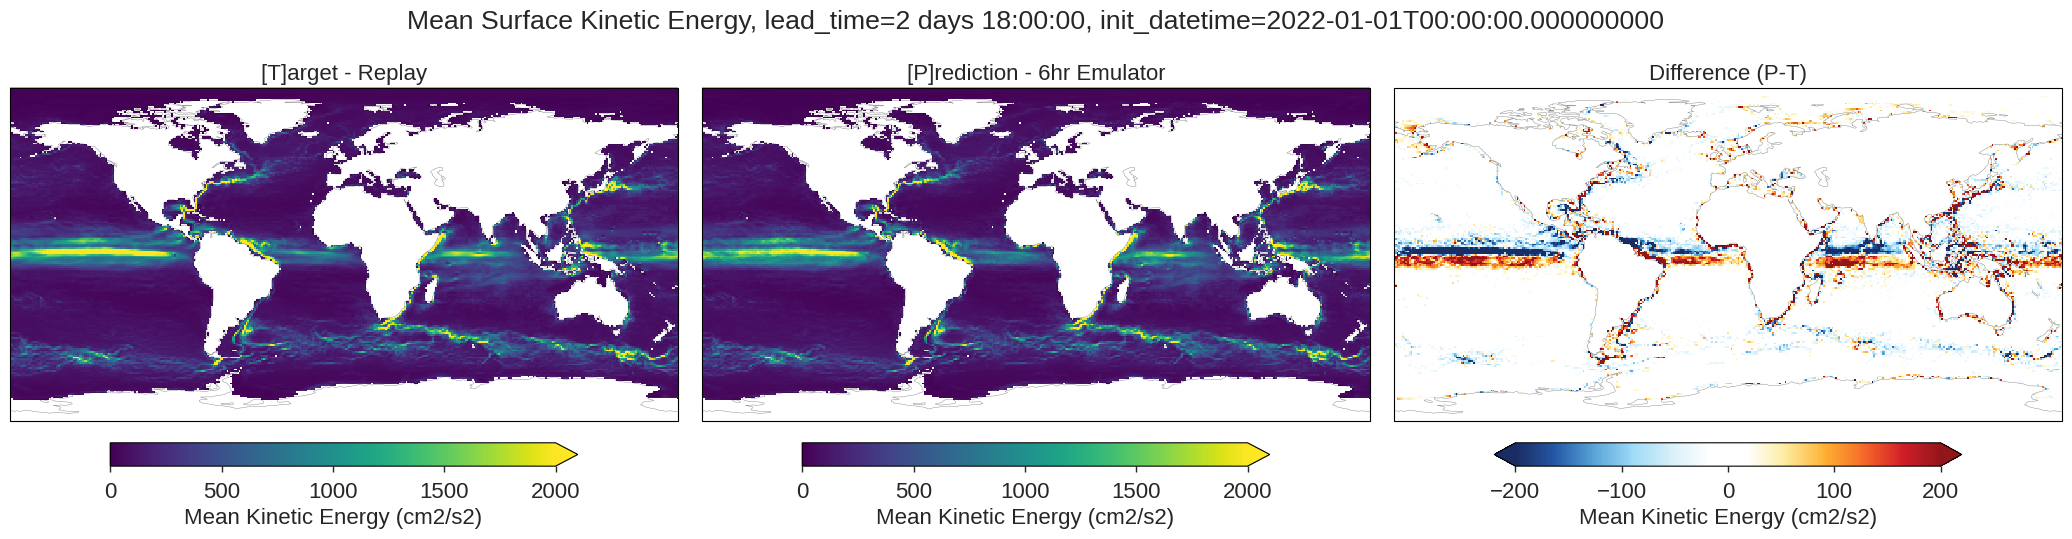

In [23]:
ileadtime = 10
iz_l = 0

fig, axs = plt.subplots(1, 3, figsize=(21,5.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "label":"Mean Kinetic Energy (cm2/s2)", "pad":0.05}, 
          "robust":True, "cmap":"viridis", "vmin":0, "vmax":2000,}

ocean_mask = xr.where(reference_truths['Replay-6h'].so.isel(time=0, lead_time=0, z_l=iz_l)==0, 0, 1)

# target - Replay
target = ke_truth['Replay-6h'].mean("time").isel(lead_time=ileadtime, z_l=iz_l).where(ocean_mask)*100*100 # convert to cm2
target.plot(ax=axs[0], transform=ccrs.PlateCarree(), **kwargs)
axs[0].coastlines(alpha=0.5)
axs[0].set_title("[T]arget - Replay")

# prediction
prediction = ke_model['ocn-only_R4_T3M_graphufs_6h'].mean("time").isel(lead_time=ileadtime, z_l=iz_l).where(ocean_mask)*100*100  # cm2
prediction.plot(ax=axs[1], transform=ccrs.PlateCarree(), **kwargs)
axs[1].coastlines(alpha=0.5)
axs[1].set_title("[P]rediction - 6hr Emulator")

# difference
diff = prediction - target
kwargs["cmap"]=cm.BlueWhiteOrangeRed
kwargs["vmin"]=-200
kwargs["vmax"]=200
diff.plot(ax=axs[2], transform=ccrs.PlateCarree(), **kwargs)
axs[2].coastlines(alpha=0.5)
axs[2].set_title("Difference (P-T)")

leadtime = pd.to_timedelta(ke_truth['Replay-6h'].lead_time[ileadtime].values, unit="D")
plt.suptitle(f"Mean Surface Kinetic Energy, lead_time={leadtime}, init_datetime={prediction.time.values}")
plt.tight_layout()
#plt.savefig(os.path.join(_figdir, f"{variable}_{_prototype}_{_expt}.png"), dpi=300)
plt.show()

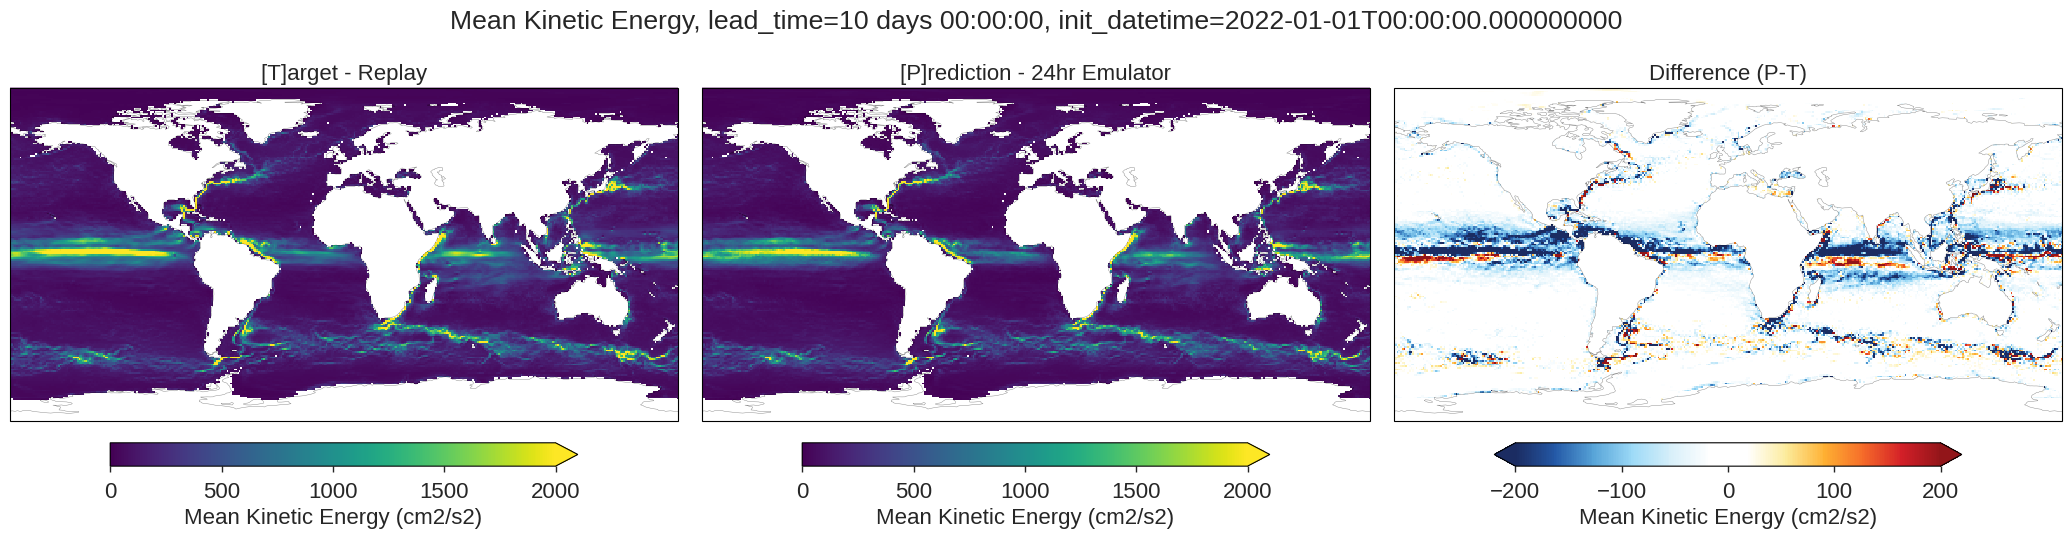

In [48]:
ileadtime = 10
iz_l = 0

fig, axs = plt.subplots(1, 3, figsize=(21,5.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "label":"Mean Kinetic Energy (cm2/s2)", "pad":0.05}, 
          "robust":True, "cmap":"viridis", "vmin":0, "vmax":2000,}

ocean_mask = xr.where(reference_truths['Replay'].so.isel(time=0, lead_time=0, z_l=iz_l)==0, 0, 1)

# target - Replay
target = ke_truth['Replay'].mean("time").isel(lead_time=ileadtime, z_l=iz_l).where(ocean_mask)*100*100 # convert to cm2
target.plot(ax=axs[0], transform=ccrs.PlateCarree(), **kwargs)
axs[0].coastlines(alpha=0.5)
axs[0].set_title("[T]arget - Replay")

# prediction
prediction = ke_model['ocn-only_R5_T1M_graphufs_24h'].mean("time").isel(lead_time=ileadtime, z_l=iz_l).where(ocean_mask)*100*100  # cm2
prediction.plot(ax=axs[1], transform=ccrs.PlateCarree(), **kwargs)
axs[1].coastlines(alpha=0.5)
axs[1].set_title("[P]rediction - 24hr Emulator")

# difference
diff = prediction - target
kwargs["cmap"]=cm.BlueWhiteOrangeRed
kwargs["vmin"]=-200
kwargs["vmax"]=200
diff.plot(ax=axs[2], transform=ccrs.PlateCarree(), **kwargs)
axs[2].coastlines(alpha=0.5)
axs[2].set_title("Difference (P-T)")

leadtime = pd.to_timedelta(ke_truth['Replay'].lead_time[ileadtime].values, unit="D")
plt.suptitle(f"Mean Kinetic Energy, lead_time={leadtime}, init_datetime={prediction.time.values}")
plt.tight_layout()
#plt.savefig(os.path.join(_figdir, f"{variable}_{_prototype}_{_expt}.png"), dpi=300)
plt.show()